# 01 Exploratory Data Analysis

            This notebook explores the main patterns in the bank marketing data before modeling. The analysis focuses on target balance, numeric distributions, contact method, prior campaign outcome, age, campaign frequency, and the leakage risk associated with `duration`.


## Load Data and Plotting Libraries

            The raw source data is used for EDA so the visuals reflect the original customer and campaign variables before cleaning or feature engineering.


In [20]:
# Load the raw data and configure plotting for the EDA notebook.

from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
RAW_DATA = PROJECT_ROOT / 'data' / 'raw' / 'bank.csv'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'
bank_data = pd.read_csv(RAW_DATA)
sns.set_theme(style='whitegrid')


## Summary Statistics

            The summary table provides a quick view of numeric ranges, frequent categories, and potential skew or outlier issues.


In [21]:
# Generate summary statistics for numeric and categorical columns.

bank_data.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11162,12,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,11162,4,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,11162,3,cellular,8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,11162.0,NaN,NaN,NaN,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0


The dataset combines customer demographics, account information, and campaign interaction variables. `balance`, `duration`, `campaign`, and `pdays` have wide ranges, so their distributions are inspected more closely.


## Target Distribution

            The target variable is visualized first to check whether the classifier will face a major class-imbalance issue.


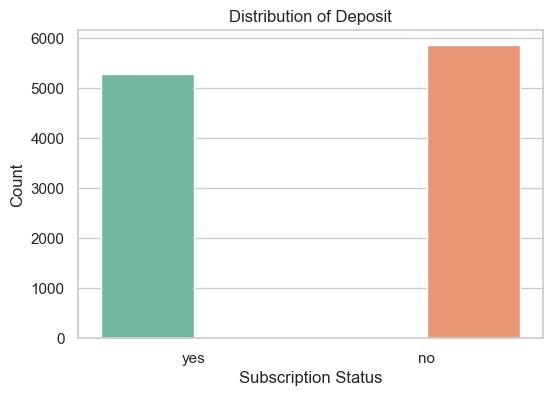

In [22]:
# Plot the count of customers who did and did not subscribe.
%matplotlib inline

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=bank_data, x='deposit', hue='deposit', palette='Set2', ax=ax)
ax.get_legend().remove()
ax.set_title('Distribution of Deposit')
ax.set_xlabel('Subscription Status')
ax.set_ylabel('Count')
plt.show()


The target is moderately balanced: about 52.6% of customers did not subscribe and 47.4% did subscribe. No resampling is needed, but balanced accuracy and class-specific metrics are still useful.


## Numerical Variable Distributions

            Histograms are used to inspect skewness, heavy tails, and unusual campaign patterns across the numeric variables.


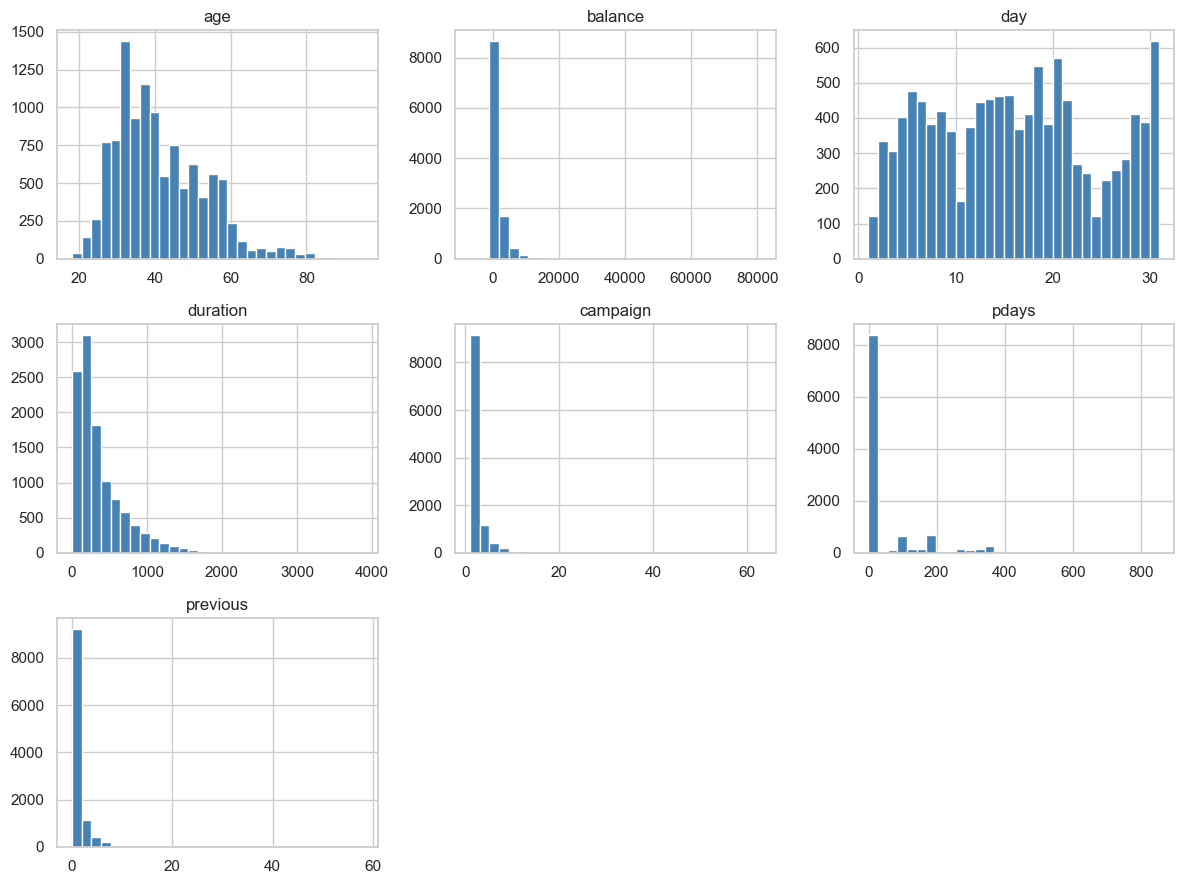

In [23]:
# Plot histograms for all numeric variables.

bank_data.select_dtypes(include='number').hist(figsize=(12, 9), bins=30, color='steelblue')
plt.tight_layout()
plt.show()


Several numeric variables are skewed, especially `balance`, `duration`, `campaign`, and `pdays`. No log transformation is applied because the production model is tree-based and can handle non-normal numeric distributions reasonably well.


## Correlation Heatmap

            The heatmap highlights numeric relationships and helps identify variables that may create leakage or dominate model performance.


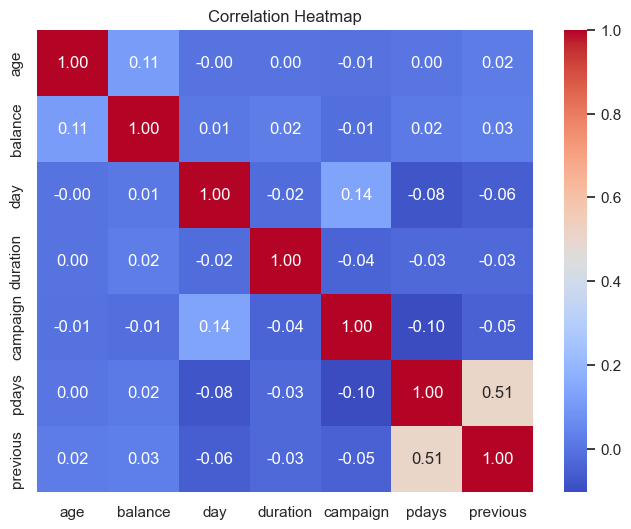

In [24]:
# Compute and plot the numeric correlation heatmap.

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(bank_data.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.show()


## Categorical Subscription Rates

            Normalized crosstabs show how subscription rates vary across categorical variables. This makes category-level patterns easier to compare than raw counts.


In [25]:
# Display normalized deposit rates for each categorical variable.

categorical = [c for c in bank_data.select_dtypes(include='object').columns if c != 'deposit']
for column in categorical:
    display(pd.crosstab(bank_data[column], bank_data['deposit'], normalize='index').round(3))


deposit,no,yes
job,,
admin.,0.527,0.473
blue-collar,0.636,0.364
entrepreneur,0.625,0.375
housemaid,0.602,0.398
management,0.493,0.507
retired,0.337,0.663
self-employed,0.538,0.462
services,0.600,0.400
student,0.253,0.747


deposit,no,yes
marital,,
divorced,0.519,0.481
married,0.566,0.434
single,0.457,0.543


deposit,no,yes
education,,
primary,0.606,0.394
secondary,0.553,0.447
tertiary,0.459,0.541
unknown,0.493,0.507


deposit,no,yes
default,,
no,0.524,0.476
yes,0.690,0.310


deposit,no,yes
housing,,
no,0.430,0.570
yes,0.634,0.366


deposit,no,yes
loan,,
no,0.505,0.495
yes,0.668,0.332


deposit,no,yes
contact,,
cellular,0.457,0.543
telephone,0.496,0.504
unknown,0.774,0.226


deposit,no,yes
month,,
apr,0.375,0.625
aug,0.547,0.453
dec,0.091,0.909
feb,0.432,0.568
jan,0.587,0.413
jul,0.586,0.414
jun,0.553,0.447
mar,0.101,0.899
may,0.672,0.328


deposit,no,yes
poutcome,,
failure,0.497,0.503
other,0.428,0.572
success,0.087,0.913
unknown,0.593,0.407


`poutcome` is the strongest categorical signal: customers with a previous successful campaign outcome are much more likely to subscribe again. `contact` also matters, with `unknown` contact type showing a much lower subscription rate than cellular or telephone contact.


## Age and Subscription

            Age is reviewed because subscription behavior may differ across life stages and financial stability profiles.


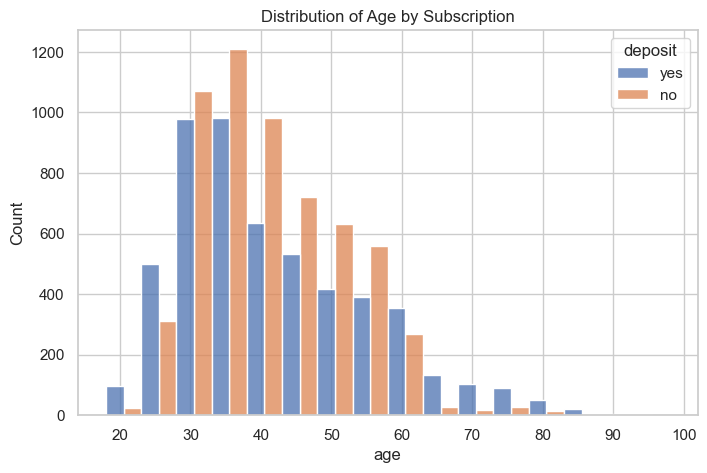

In [26]:
# Compare the age distribution for subscribers and non-subscribers.

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=bank_data, x='age', hue='deposit', binwidth=5, multiple='dodge', ax=ax)
ax.set_title('Distribution of Age by Subscription')
plt.show()


## Campaign Frequency and Subscription

            Campaign frequency is evaluated as a proportion because raw counts can hide how subscription rate changes as the number of contacts increases.


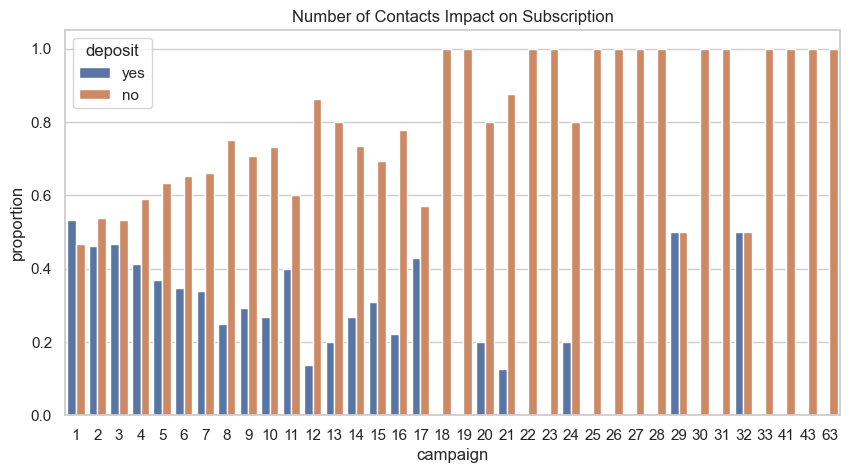

In [27]:
# Plot subscription proportions by number of campaign contacts.

campaign_rates = bank_data.groupby('campaign')['deposit'].value_counts(normalize=True).rename('proportion').reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=campaign_rates, x='campaign', y='proportion', hue='deposit', ax=ax)
ax.set_title('Number of Contacts Impact on Subscription')
plt.show()


Customers contacted many times during the same campaign appear less likely to subscribe. This may indicate lower customer interest or contact fatigue.


## Save EDA Figures as Project Artifacts

            The visuals are also saved as PNG files under `reports/figures/` so they can be reused in documentation, presentations, or dashboards without rerunning notebook cells.


In [28]:
# Export the EDA plots as reusable project artifacts.

from src.visualization.create_plots import create_all_plots

create_all_plots(RAW_DATA, FIGURE_DIR)
sorted(path.name for path in FIGURE_DIR.glob('*.png'))


['age_by_subscription.png',
 'campaign_subscription_proportion.png',
 'categorical_deposit_proportions.png',
 'correlation_heatmap.png',
 'deposit_distribution.png',
 'numerical_boxplots.png',
 'numerical_histograms.png']